In [1]:
import sys
print("PYTHON EXECUTABLE:")
print(sys.executable)



PYTHON EXECUTABLE:
/home/jvelareb/miniforge3/envs/py_all/bin/python


In [2]:
import os
os.environ["PYTHONNOUSERSITE"] = "1"


VQE COMPLETO PARA MOLÉCULA H₂ (Qiskit Nature 0.7.2 / Qiskit 1.x)
Python exe: /home/jvelareb/miniforge3/envs/py_all/bin/python

[PASO 1] ESPECIFICACIÓN MOLECULAR
--------------------------------------------------------------------------------
Geometría: H 0 0 0; H 0 0 0.7414
Base:      sto3g
Carga:     0
Spin:      0 (multiplicidad 1)

[PASO 2] DRIVER (PySCF)
--------------------------------------------------------------------------------

[PASO 3] EJECUCIÓN DRIVER + RESULTADO ELECTRÓNICO (Nature 0.7.2)
--------------------------------------------------------------------------------
✓ Driver ejecutado (PySCF OK)
Número de partículas (α,β): (1, 1)
Orbitales espaciales:       2
Repulsión nuclear:          0.7137539937 Ha

[PASO 4] MAPEO A QUBITS (Jordan-Wigner)
--------------------------------------------------------------------------------
Qubits requeridos: 4
Términos de Pauli: 15

Primeros 5 términos:
  1. -0.81261796+0.00000000j * IIII
  2. +0.17119775+0.00000000j * IIIZ
  3. -0.22278

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman


  Eval  25: E = -1.8195884012 Ha
  Eval  30: E = -1.8369062236 Ha
  Eval  35: E = -1.8504304594 Ha
  Eval  40: E = -1.8510150205 Ha

✓ VQE terminado
Evaluaciones: 44

[PASO 7] RESULTADOS
--------------------------------------------------------------------------------
Energía electrónica VQE:   -1.8510241256 Ha
Repulsión nuclear:         0.7137539937 Ha
Energía total VQE:         -1.1372701319 Ha

HF (ref):  -1.11733 Ha
FCI (ref): -1.17463 Ha
Error vs FCI: 0.037360 Ha (37.360 mHa)

Parámetros óptimos:
[ 6.28303103  3.14179547 -3.25470399]

[CONVERGENCIA]
--------------------------------------------------------------------------------
✓ Guardado: vqe_convergence_h2.png

CÁLCULO VQE COMPLETADO


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were fou

✓ Gráfico guardado como 'vqe_simple_plot_h2.png'


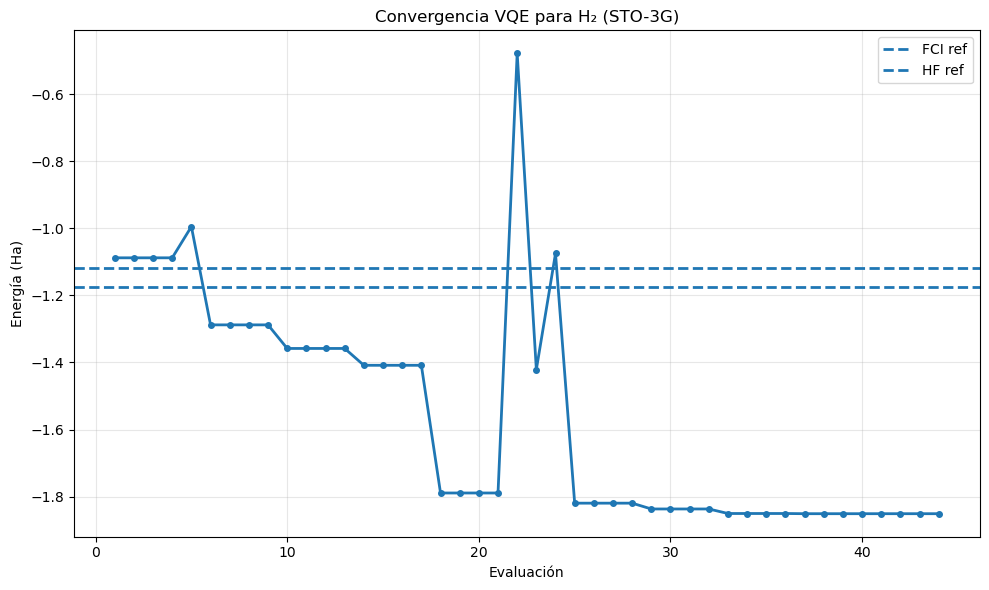

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman, Latin Modern Roman
findfont: Generic family 'serif' not found because none of the following families were fou

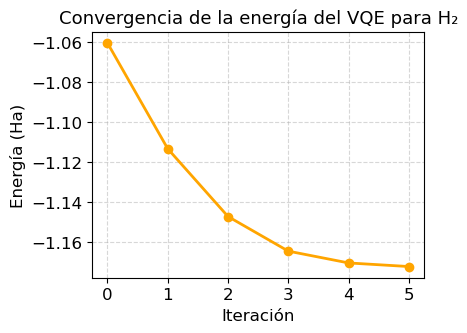

In [5]:
# ============================================================================
# VQE COMPLETO PARA MOLÉCULA H2 (Qiskit 1.x + Qiskit Nature 0.7.2 + PySCF)
# Compatible con tu entorno WSL: py_all
# ============================================================================

import sys
from typing import List

import numpy as np
import matplotlib.pyplot as plt

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import StatevectorEstimator

print("=" * 80)
print("VQE COMPLETO PARA MOLÉCULA H₂ (Qiskit Nature 0.7.2 / Qiskit 1.x)")
print("=" * 80)

# ============================================================================
# PASO 0: SANITY CHECK (kernel/entorno)
# ============================================================================
print("Python exe:", sys.executable)

# ============================================================================
# PASO 1: ESPECIFICACIÓN MOLECULAR
# ============================================================================
print("\n[PASO 1] ESPECIFICACIÓN MOLECULAR")
print("-" * 80)

BOND_LENGTH = 0.7414  # Å
GEOMETRY = f"H 0 0 0; H 0 0 {BOND_LENGTH}"
BASIS_SET = "sto3g"
CHARGE = 0
SPIN = 0  # singlete

print(f"Geometría: {GEOMETRY}")
print(f"Base:      {BASIS_SET}")
print(f"Carga:     {CHARGE}")
print(f"Spin:      {SPIN} (multiplicidad {SPIN + 1})")

# ============================================================================
# PASO 2: DRIVER PySCF
# ============================================================================
print("\n[PASO 2] DRIVER (PySCF)")
print("-" * 80)

driver = PySCFDriver(
    atom=GEOMETRY,
    basis=BASIS_SET,
    charge=CHARGE,
    spin=SPIN,
    unit=DistanceUnit.ANGSTROM,
)

# ============================================================================
# PASO 3: EJECUCIÓN DRIVER + RESULTADOS (Nature 0.7.2)
# ============================================================================
print("\n[PASO 3] EJECUCIÓN DRIVER + RESULTADO ELECTRÓNICO (Nature 0.7.2)")
print("-" * 80)

driver_result = driver.run()
print("✓ Driver ejecutado (PySCF OK)")

# Metadatos del cálculo
num_particles = driver_result.num_particles
num_spatial_orbitals = driver_result.num_spatial_orbitals
nuclear_repulsion = float(driver_result.nuclear_repulsion_energy)

# IMPORTANTE: driver_result.hamiltonian es ElectronicEnergy,
# el FermionicOp real se obtiene con .second_q_op()
second_q_hamiltonian = driver_result.hamiltonian.second_q_op()

print(f"Número de partículas (α,β): {num_particles}")
print(f"Orbitales espaciales:       {num_spatial_orbitals}")
print(f"Repulsión nuclear:          {nuclear_repulsion:.10f} Ha")

# ============================================================================
# PASO 4: MAPEO A QUBITS (JORDAN-WIGNER)
# ============================================================================
print("\n[PASO 4] MAPEO A QUBITS (Jordan-Wigner)")
print("-" * 80)

mapper = JordanWignerMapper()

# Mapear FermionicOp -> SparsePauliOp
qubit_hamiltonian = mapper.map(second_q_hamiltonian)

num_qubits_required = qubit_hamiltonian.num_qubits
pauli_terms = qubit_hamiltonian.to_list()

print(f"Qubits requeridos: {num_qubits_required}")
print(f"Términos de Pauli: {len(pauli_terms)}")
print("\nPrimeros 5 términos:")
for i, (pauli_str, coeff) in enumerate(pauli_terms[:5], start=1):
    print(f"  {i}. {coeff:+.8f} * {pauli_str}")

# ============================================================================
# PASO 5: ANSATZ (Hartree-Fock + UCCSD)
# ============================================================================
print("\n[PASO 5] ANSATZ (Hartree-Fock + UCCSD)")
print("-" * 80)

hf_state = HartreeFock(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
)

ansatz = UCCSD(
    num_spatial_orbitals=num_spatial_orbitals,
    num_particles=num_particles,
    qubit_mapper=mapper,
    initial_state=hf_state,
)

print(f"Parámetros variacionales: {ansatz.num_parameters}")
print(f"Profundidad (aprox):      {ansatz.decompose().depth()}")

# ============================================================================
# PASO 6: VQE
# ============================================================================
print("\n[PASO 6] VQE")
print("-" * 80)

estimator = StatevectorEstimator()
optimizer = SLSQP(maxiter=120, eps=1e-6)

energy_history: List[float] = []

def callback(eval_count, params, mean, metadata):
    # Firma qiskit-algorithms 0.4: callback(eval_count, params, mean, metadata)
    energy_history.append(float(mean))
    if eval_count == 1 or eval_count % 5 == 0:
        print(f"  Eval {eval_count:3d}: E = {float(mean): .10f} Ha")

vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer, callback=callback)

print("\nEjecutando VQE...")
result = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

vqe_electronic_energy = float(np.real(result.eigenvalue))
vqe_total_energy = vqe_electronic_energy + nuclear_repulsion

print("\n✓ VQE terminado")
print(f"Evaluaciones: {len(energy_history)}")

# ============================================================================
# PASO 7: RESULTADOS
# ============================================================================
print("\n[PASO 7] RESULTADOS")
print("-" * 80)

print(f"Energía electrónica VQE:   {vqe_electronic_energy:.10f} Ha")
print(f"Repulsión nuclear:         {nuclear_repulsion:.10f} Ha")
print(f"Energía total VQE:         {vqe_total_energy:.10f} Ha")

# Referencias típicas H2 STO-3G (aprox; pueden variar ligeramente)
HF_REF  = -1.11733
FCI_REF = -1.17463

print(f"\nHF (ref):  {HF_REF:.5f} Ha")
print(f"FCI (ref): {FCI_REF:.5f} Ha")
print(f"Error vs FCI: {abs(vqe_total_energy - FCI_REF):.6f} Ha "
      f"({abs(vqe_total_energy - FCI_REF)*1000:.3f} mHa)")

print("\nParámetros óptimos:")
print(getattr(result, "optimal_point", getattr(result, "x", None)))

# ============================================================================
# CONVERGENCIA (GRÁFICO)
# ============================================================================
print("\n[CONVERGENCIA]")
print("-" * 80)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(energy_history) + 1), energy_history, marker="o", linewidth=2, markersize=4)
plt.axhline(y=FCI_REF, linestyle="--", linewidth=2, label="FCI ref")
plt.axhline(y=HF_REF, linestyle="--", linewidth=2, label="HF ref")
plt.xlabel("Evaluación")
plt.ylabel("Energía (Ha)")
plt.title("Convergencia VQE para H₂ (STO-3G)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("vqe_convergence_h2.png", dpi=150)
print("✓ Guardado: vqe_convergence_h2.png")

print("\n" + "=" * 80)
print("CÁLCULO VQE COMPLETADO")
print("=" * 80)

import matplotlib.pyplot as plt

# Datos de energía por iteración
energy_history = [-1.0605, -1.1134, -1.1473, -1.1646, -1.1705, -1.1723]

# Configurar fuente sin usar LaTeX
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Latin Modern Roman"],
    "font.size": 12
})

plt.figure(figsize=(4.5, 3.5))
plt.plot(range(len(energy_history)), energy_history, marker="o", color="orange", linewidth=2)

plt.xlabel("Iteración", fontsize=12)
plt.ylabel("Energía (Ha)", fontsize=12)
plt.title("Convergencia de la energía del VQE para H₂", fontsize=13)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("vqe_simple_plot_h2.png", dpi=300)

print("✓ Gráfico guardado como 'vqe_simple_plot_h2.png'")




In [9]:
# ============================================================================
# H2: OPTIMIZACIÓN DE GEOMETRÍA + CURVAS DE ENERGÍA
# HF vs FCI exacta (PySCF clásico) vs VQE-UCCSD (QC con Qiskit)
#
# Compatible con:
# - qiskit 1.x
# - qiskit-nature 0.7.2
# - qiskit-algorithms 0.4.0  (IMPORTANTE: sin initial_point en compute_minimum_eigenvalue)
# - PySCF instalado
#
# Entorno recomendado: WSL + conda env py_all (el tuyo)
# ============================================================================

import sys
import time
from dataclasses import dataclass, asdict
from typing import List, Optional, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# PARTE CLÁSICA (TEÓRICA): PySCF
# -------------------------
from pyscf import gto, scf, fci

# -------------------------
# PARTE QC (CUÁNTICA): Qiskit
# -------------------------
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP, COBYLA, SPSA
from qiskit.primitives import StatevectorEstimator

# ============================================================================
# CONFIGURACIÓN
# ============================================================================

print("=" * 95)
print("H2: HF vs FCI exacta (PySCF) vs VQE-UCCSD (QC con Qiskit)")
print("Qiskit Nature 0.7.2 / Qiskit 1.x / qiskit-algorithms 0.4.0 / PySCF")
print("=" * 95)
print("Python exe:", sys.executable)

# Distancias H-H (Å) para la curva (ajusta si quieres más resolución)
BOND_LENGTHS = np.round(np.linspace(0.35, 2.50, 18), 3)  # 18 puntos

# Bases gaussianas a probar
BASIS_LIST = ["sto3g", "6-31g", "cc-pvdz"]

CHARGE = 0
SPIN = 0  # singlete

# VQE settings
USE_VQE = True
OPTIMIZER_NAME = "SLSQP"   # "SLSQP" | "COBYLA" | "SPSA"
MAXITER = 140
PRINT_EVERY_VQE_EVAL = 0   # 0 = silencioso (solo resumen), 10 = imprime cada 10 evals

# Salidas
CSV_OUT = "h2_curve_results.csv"
PLOT_OUT = "h2_curve_plot.png"
OPT_GEOM_TXT = "h2_optimized_geometry.txt"

# ============================================================================
# FUNCIONES AUXILIARES
# ============================================================================

def geometry_h2(bond_length: float) -> str:
    """Formato de geometría usado por PySCFDriver (y legible)."""
    return f"H 0 0 0; H 0 0 {bond_length}"

def make_optimizer(name: str, maxiter: int):
    name = name.upper().strip()
    if name == "SLSQP":
        return SLSQP(maxiter=maxiter, eps=1e-6)
    if name == "COBYLA":
        return COBYLA(maxiter=maxiter)
    if name == "SPSA":
        return SPSA(maxiter=maxiter)
    raise ValueError(f"Optimizador no soportado: {name}")

# ============================================================================
# PARTE CLÁSICA (TEÓRICA): HF y FCI EXACTA con PySCF
# ============================================================================

def pyscf_hf_fci(bond_length: float, basis: str) -> Tuple[float, float]:
    """
    Devuelve (HF_total, FCI_total) con PySCF.
    Esto es cálculo TEÓRICO CLÁSICO (no QC).
    """
    mol = gto.M(
        atom=geometry_h2(bond_length),
        basis=basis,
        charge=CHARGE,
        spin=SPIN,
        unit="Angstrom",
        verbose=0,
    )
    mf = scf.RHF(mol).run()
    hf_total = float(mf.e_tot)

    # FCI exacta (dentro de esta base)
    cisolver = fci.FCI(mol, mf.mo_coeff)
    fci_total, _ = cisolver.kernel()
    fci_total = float(fci_total)

    return hf_total, fci_total

# ============================================================================
# PARTE QC (CUÁNTICA): VQE-UCCSD con Qiskit
# ============================================================================

def vqe_uccsd_qiskit(bond_length: float, basis: str, optimizer_name: str, maxiter: int):
    """
    Ejecuta QC: VQE-UCCSD (Qiskit).
    Devuelve:
      (vqe_total, vqe_electronic, nuclear_repulsion, num_qubits, num_params, n_evals)

    NOTA importante: qiskit-algorithms 0.4.0 NO acepta initial_point en compute_minimum_eigenvalue.
    """
    geom = geometry_h2(bond_length)

    # Driver (usa PySCF por debajo, pero el flujo es el de Qiskit Nature)
    driver = PySCFDriver(
        atom=geom,
        basis=basis,
        charge=CHARGE,
        spin=SPIN,
        unit=DistanceUnit.ANGSTROM,
    )
    driver_result = driver.run()

    num_particles = driver_result.num_particles
    num_spatial_orbitals = driver_result.num_spatial_orbitals
    nuclear_repulsion = float(driver_result.nuclear_repulsion_energy)

    # ElectronicEnergy -> FermionicOp (esto ya se puede mapear)
    second_q_hamiltonian = driver_result.hamiltonian.second_q_op()

    # Mapper fermiónico -> qubits
    mapper = JordanWignerMapper()
    qubit_hamiltonian = mapper.map(second_q_hamiltonian)

    num_qubits = int(qubit_hamiltonian.num_qubits)

    # Circuito inicial HF + ansatz UCCSD (QC)
    hf_state = HartreeFock(
        num_spatial_orbitals=num_spatial_orbitals,
        num_particles=num_particles,
        qubit_mapper=mapper,
    )
    ansatz = UCCSD(
        num_spatial_orbitals=num_spatial_orbitals,
        num_particles=num_particles,
        qubit_mapper=mapper,
        initial_state=hf_state,
    )
    num_params = int(ansatz.num_parameters)

    estimator = StatevectorEstimator()      # simulador ideal (sin ruido)
    optimizer = make_optimizer(optimizer_name, maxiter=maxiter)

    energy_history: List[float] = []

    def callback(eval_count, params, mean, metadata):
        energy_history.append(float(mean))
        if PRINT_EVERY_VQE_EVAL and (eval_count == 1 or eval_count % PRINT_EVERY_VQE_EVAL == 0):
            print(f"    [QC] eval {eval_count:4d}: E_elec={float(mean): .10f} Ha")

    vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer, callback=callback)

    # En 0.4.0: NO pasar initial_point aquí
    res = vqe.compute_minimum_eigenvalue(qubit_hamiltonian)

    vqe_electronic = float(np.real(res.eigenvalue))
    vqe_total = vqe_electronic + nuclear_repulsion

    return vqe_total, vqe_electronic, nuclear_repulsion, num_qubits, num_params, len(energy_history)

# ============================================================================
# ESTRUCTURA RESULTADOS
# ============================================================================

@dataclass
class PointResult:
    basis: str
    bond_length: float

    # Teórico clásico (PySCF)
    hf_total: Optional[float] = None
    fci_total: Optional[float] = None

    # QC (Qiskit)
    vqe_total: Optional[float] = None
    vqe_electronic: Optional[float] = None
    nuclear_repulsion: Optional[float] = None
    num_qubits: Optional[int] = None
    uccsd_params: Optional[int] = None
    vqe_evals: Optional[int] = None

    # Timing
    t_classical_s: Optional[float] = None
    t_vqe_s: Optional[float] = None

    # Error
    err: Optional[str] = None

# ============================================================================
# EJECUCIÓN: CURVAS PARA CADA BASIS
# ============================================================================

results: List[PointResult] = []

for basis in BASIS_LIST:
    print("\n" + "=" * 95)
    print(f"BASE GAUSSIANA: {basis}")
    print("=" * 95)

    for R in BOND_LENGTHS:
        pr = PointResult(basis=basis, bond_length=float(R))
        print(f"\n▶ R = {R} Å | basis={basis}")

        # ---- CLÁSICO TEÓRICO: HF + FCI exacta (PySCF)
        try:
            t0 = time.time()
            hf_total, fci_total = pyscf_hf_fci(R, basis)
            pr.t_classical_s = time.time() - t0
            pr.hf_total = hf_total
            pr.fci_total = fci_total
            print(f"  [TEÓRICO-CLÁSICO] HF total : {hf_total: .10f} Ha")
            print(f"  [TEÓRICO-CLÁSICO] FCI total: {fci_total: .10f} Ha")
        except Exception as e:
            pr.err = f"PySCF HF/FCI error: {e}"
            print("  ✗ Error PySCF HF/FCI:", e)

        # ---- QC: VQE-UCCSD (Qiskit)
        if USE_VQE:
            try:
                t0 = time.time()
                vqe_total, vqe_elec, e_nuc, nqubits, nparams, nevals = vqe_uccsd_qiskit(
                    R, basis, optimizer_name=OPTIMIZER_NAME, maxiter=MAXITER
                )
                pr.t_vqe_s = time.time() - t0
                pr.vqe_total = vqe_total
                pr.vqe_electronic = vqe_elec
                pr.nuclear_repulsion = e_nuc
                pr.num_qubits = nqubits
                pr.uccsd_params = nparams
                pr.vqe_evals = nevals

                # Comparación vs FCI (exacta)
                if pr.fci_total is not None:
                    err_fci = abs(vqe_total - pr.fci_total)
                    print(f"  [QC] VQE total: {vqe_total: .10f} Ha  | error vs FCI: {err_fci:.6f} Ha ({err_fci*1000:.2f} mHa)")
                else:
                    print(f"  [QC] VQE total: {vqe_total: .10f} Ha")

                print(f"  [QC] qubits={nqubits}, params={nparams}, evals={nevals}, opt={OPTIMIZER_NAME}")

            except Exception as e:
                pr.err = (pr.err + " | " if pr.err else "") + f"VQE error: {e}"
                print("  ✗ Error VQE:", e)

        results.append(pr)

# ============================================================================
# RESULTADOS: CSV
# ============================================================================

df = pd.DataFrame([asdict(r) for r in results])
df.sort_values(["basis", "bond_length"], inplace=True)
df.to_csv(CSV_OUT, index=False)

print("\n" + "=" * 95)
print("✓ CSV guardado:", CSV_OUT)
print("=" * 95)

# ============================================================================
# GEOMETRÍA OPTIMIZADA (distancia mínima de energía)
# Elegimos por defecto la mínima energía FCI (exacta) por cada base
# (si FCI no existe, cae a HF; si tampoco, cae a VQE).
# ============================================================================

opt_lines = []
opt_summary: Dict[str, Dict[str, float]] = {}

print("\n" + "=" * 95)
print("GEOMETRÍA OPTIMIZADA (por base)")
print("=" * 95)

for basis in BASIS_LIST:
    d = df[df["basis"] == basis].copy()

    # Preferencia: FCI -> HF -> VQE
    if d["fci_total"].notna().any():
        col = "fci_total"
        label = "FCI (exacta, teórico)"
    elif d["hf_total"].notna().any():
        col = "hf_total"
        label = "HF (teórico)"
    else:
        col = "vqe_total"
        label = "VQE (QC)"

    d2 = d.dropna(subset=[col])
    idx = d2[col].idxmin()
    row = d2.loc[idx]

    Ropt = float(row["bond_length"])
    Eopt = float(row[col])

    geom_str = geometry_h2(Ropt)

    opt_summary[basis] = {"R_opt_A": Ropt, "E_opt_Ha": Eopt, "method": label}

    print(f"\nBase: {basis}")
    print(f"  Método para optimizar: {label}")
    print(f"  R_opt (Å): {Ropt:.6f}")
    print(f"  Energía mínima: {Eopt:.10f} Ha")
    print(f"  Geometría optimizada (lista para PP/molecular):")
    print(f"    {geom_str}")

    opt_lines.append(f"basis={basis}")
    opt_lines.append(f"method={label}")
    opt_lines.append(f"R_opt_A={Ropt:.6f}")
    opt_lines.append(f"E_opt_Ha={Eopt:.10f}")
    opt_lines.append(f"geometry={geom_str}")
    opt_lines.append("")

with open(OPT_GEOM_TXT, "w", encoding="utf-8") as f:
    f.write("\n".join(opt_lines))

print("\n✓ Geometrías optimizadas guardadas en:", OPT_GEOM_TXT)

# ============================================================================
# GRÁFICO: Curvas HF vs FCI vs VQE por base
# ============================================================================

print("\nGenerando gráfico:", PLOT_OUT)
plt.figure(figsize=(13, 7))

for basis in BASIS_LIST:
    d = df[df["basis"] == basis].copy()
    x = d["bond_length"].values

    if d["hf_total"].notna().any():
        plt.plot(x, d["hf_total"].values, marker="o", linewidth=2, label=f"HF ({basis})")

    if d["fci_total"].notna().any():
        plt.plot(x, d["fci_total"].values, marker="o", linewidth=2, label=f"FCI exacta ({basis})")

    if USE_VQE and d["vqe_total"].notna().any():
        plt.plot(x, d["vqe_total"].values, marker="o", linewidth=2, label=f"VQE-UCCSD ({basis})")

plt.xlabel("Distancia H–H (Å)")
plt.ylabel("Energía total (Ha)")
plt.title("H₂: HF vs FCI exacta (PySCF) vs VQE-UCCSD (QC con Qiskit)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(PLOT_OUT, dpi=170)
print("✓ Plot guardado:", PLOT_OUT)

print("\n" + "=" * 95)
print("FIN (curvas + comparación QC vs teórico + geometría optimizada)")
print("=" * 95)


H2: HF vs FCI exacta (PySCF) vs VQE-UCCSD (QC con Qiskit)
Qiskit Nature 0.7.2 / Qiskit 1.x / qiskit-algorithms 0.4.0 / PySCF
Python exe: /home/jvelareb/miniforge3/envs/py_all/bin/python

BASE GAUSSIANA: sto3g

▶ R = 0.35 Å | basis=sto3g
  [TEÓRICO-CLÁSICO] HF total : -0.7804549021 Ha
  [TEÓRICO-CLÁSICO] FCI total: -0.7892693924 Ha
  [QC] VQE total: -0.7892688595 Ha  | error vs FCI: 0.000001 Ha (0.00 mHa)
  [QC] qubits=4, params=3, evals=38, opt=SLSQP

▶ R = 0.476 Å | basis=sto3g
  [TEÓRICO-CLÁSICO] HF total : -1.0192135090 Ha
  [TEÓRICO-CLÁSICO] FCI total: -1.0307529188 Ha
  [QC] VQE total: -1.0307529184 Ha  | error vs FCI: 0.000000 Ha (0.00 mHa)
  [QC] qubits=4, params=3, evals=32, opt=SLSQP

▶ R = 0.603 Å | basis=sto3g
  [TEÓRICO-CLÁSICO] HF total : -1.1020970887 Ha
  [TEÓRICO-CLÁSICO] FCI total: -1.1173549422 Ha
  [QC] VQE total: -1.1173548239 Ha  | error vs FCI: 0.000000 Ha (0.00 mHa)
  [QC] qubits=4, params=3, evals=53, opt=SLSQP

▶ R = 0.729 Å | basis=sto3g
  [TEÓRICO-CLÁSICO] HF

KeyboardInterrupt: 